Imports

In [95]:
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt

In [96]:
DATA_PATH='Data/mnist.npz'

#### Data processing

Load data using numpy

In [97]:
data = np.load(DATA_PATH)
print(data.files)

['x_test', 'x_train', 'y_train', 'y_test']


In [98]:
X_train = data['x_train']
y_train = data['y_train']

X_test = data['x_test']
y_test = data['y_test']

In [99]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Flatten and Normalize

In [100]:
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

In [101]:
print(X_train.shape, y_train.shape)  
print(X_test.shape, y_test.shape)   

(60000, 784) (60000,)
(10000, 784) (10000,)


Select data corresponding to classes 0, 1 and 2

In [102]:
classes = [0, 1, 2]

y_train_idx = [i for i in range(y_train.shape[0]) if y_train[i] in classes]
y_test_idx = [i for i in range(y_test.shape[0]) if y_test[i] in classes]

X_train = X_train[y_train_idx, :]
X_test = X_test[y_test_idx, :]
y_train = y_train[y_train_idx]
y_test = y_test[y_test_idx]

In [103]:
print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)

X_train.shape: (18623, 784)
y_train.shape: (18623,)
X_test.shape: (3147, 784)
y_test.shape: (3147,)


In [104]:
d = X_train.shape[1]
N_train = X_train.shape[0]
N_test = X_test.shape[0]

X = (N,d)

y = (N,)

d = 28x28 = 784

For train, N=18623

For test, N=3147

In [105]:
def plot_images(X, title, cols=5):
    num_images = len(X)
    rows = (num_images + cols - 1) // cols
    
    plt.figure(figsize=(cols*2, rows*2))
    if title:
        plt.suptitle(title)
    
    for i in range(num_images):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show() 

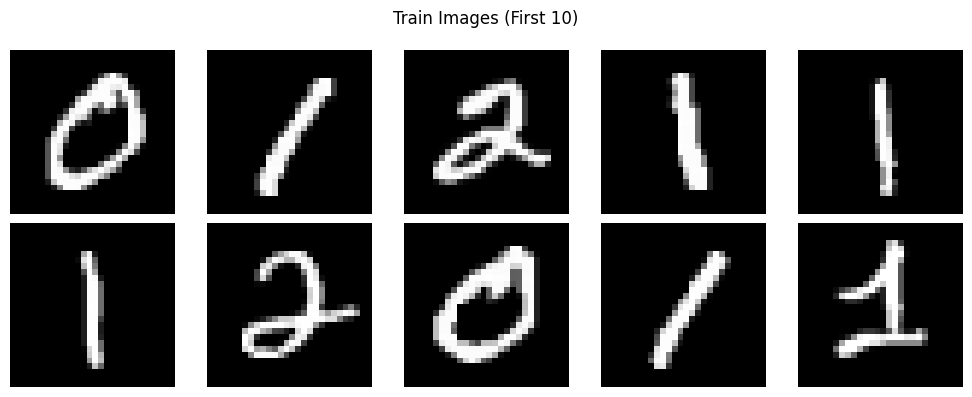

In [106]:
plot_images(X_train[:10],'Train Images (First 10)')

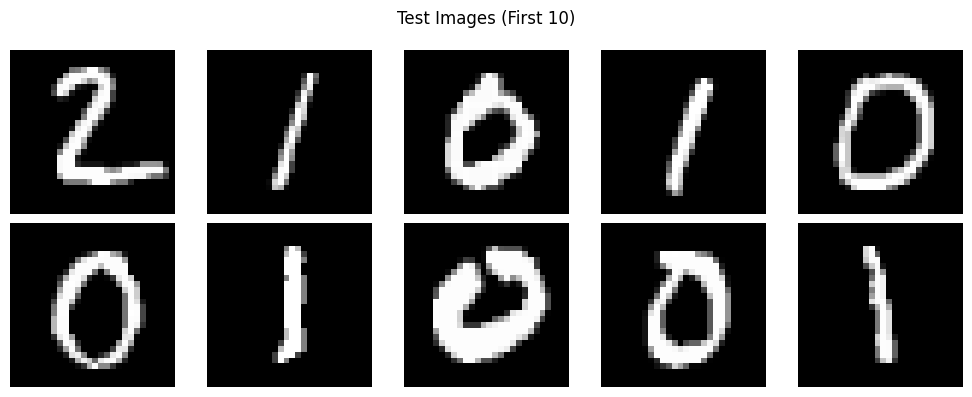

In [107]:
plot_images(X_test[:10],'Test Images (First 10)')

#### PCA implementation

Mean of the data:

$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$

Mean centered data:

$X_c = X - \mu$

Covariance matrix:

$S = \frac{X_c X_c^T}{N}$

Eigenvalue decomposition:

$S u_i = \lambda_i u_i$

Projection matrix using the top $p$ eigenvectors:

$U_p = [u_1, u_2, ..., u_p]$

Low dimensional representation:

$Y = U_p^T X_c$

In [108]:
def pca_fit(X,p):
    
    mu = np.mean(X, axis=0, keepdims=True)
    X_centered = X - mu

    cov_matrix = 1/X.shape[0] * X_centered.T @ X_centered

    # Eigenvalue problem on covariance matrix
    eigvalues, eigvectors = np.linalg.eigh(cov_matrix)

    # sort eigenvectors in descending order of eigenvalues
    eig_idx = np.argsort(eigvalues)[::-1]      
    eigvalues = eigvalues[eig_idx]
    eigvectors = eigvectors[:, eig_idx] 

    eigenvectors_p = eigvectors[:, :p]

    return eigenvectors_p, mu
    
def pca_transform(X, eigenvectors_p, mu):
    return (X - mu) @ eigenvectors_p

In [109]:
# Apply PCA 
p = 10 
eigenvectors_p, mu = pca_fit(X_train, p)
X_train_pca = pca_transform(X_train, eigenvectors_p, mu) 
X_test_pca = pca_transform(X_test, eigenvectors_p, mu) 

print(f"PCA dimension of train data: {X_train_pca.shape[1]}") 
print(f"PCA dimension of test data: {X_test_pca.shape[1]}") 

PCA dimension of train data: 10
PCA dimension of test data: 10


#### Decision Tree Utilities

We implement the **Weighted Gini Index** to select the best split.

The Gini impurity of a node $S$ is defined as:
$$
\text{Gini}(S) = 1 - \sum_{k=1}^{K} p_k^2
$$
where $p_k$ is the proportion of samples belonging to class $k$.

For a split into left ($L$) and right ($R$) nodes, the **weighted Gini index** is:
$$
\text{Gini}_{\text{weighted}} = \frac{|L|}{|S|} \cdot \text{Gini}(L) + \frac{|R|}{|S|} \cdot \text{Gini}(R)
$$

We use the **mean or median of each feature** as candidate thresholds:
$$
t = \text{mean}(X_j) \quad \text{or} \quad t = \text{median}(X_j)
$$

The split is performed as:
$$
L = \{x \mid x_j \le t\}, \quad R = \{x \mid x_j > t\}
$$

In [110]:
# Calculates Gini(S)
def get_gini(y, classes):
    if len(y) == 0: return 0
    pk = [np.sum(y == c) / len(y) for c in classes]
    return 1 - np.sum([p**2 for p in pk])

# Selects the best split by comparing multiple thresholds
def get_best_split(X, y, classes, k=None):
    p_total = X.shape[1]
    # Randomly select k (if not None else all p) features at every split for RF
    feature_indices = np.random.choice(p_total, k, replace=False) if k else range(p_total)

    best_gini_w = float('inf')
    best_split = None
    
    for f_idx in feature_indices:
        # Compare Mean and Median as candidate thresholds 
        candidates = [("mean", np.mean(X[:, f_idx])), ("median", np.median(X[:, f_idx]))]
        for name, threshold in candidates:
            left_m, right_m = X[:, f_idx] <= threshold, X[:, f_idx] > threshold
            if np.sum(left_m) == 0 or np.sum(right_m) == 0: continue    # Skipping bad splits
                
            # Weighted Gini Index calculation 
            gini_w = (np.sum(left_m)/len(y)) * get_gini(y[left_m], classes) + \
                     (np.sum(right_m)/len(y)) * get_gini(y[right_m], classes)
            
            # Keeping best split with lowest weighted Gini
            if gini_w < best_gini_w:
                best_gini_w = gini_w
                best_split = {'f': f_idx, 't': threshold, 
                              'metric': name,
                              'lm': left_m, 'rm': right_m, 
                              'red': get_gini(y, classes) - gini_w}
    return best_split

#### Training a 3-Terminal Node Tree

We grow a tree with exactly 3 terminal nodes by first splitting the root and then performing a second split on the child node that yields the highest Gini reduction.

In [ ]:
def build_3node_tree(X, y, classes, k=None):
    # Finding majority class label in current data
    majority_label = np.argmax(np.bincount(y.astype(int), minlength=int(max(classes)+1))) if len(y) > 0 else classes[0]
    
    # Finding best root split 
    root = get_best_split(X, y, classes, k)
    if root is None: 
        return {'is_leaf': True, 'label': majority_label}
    
    # Try splitting both l and r child nodes to reach 3 terminal nodes
    l_split = get_best_split(X[root['lm']], y[root['lm']], classes, k)
    r_split = get_best_split(X[root['rm']], y[root['rm']], classes, k)
    
    # Reduction in Gini Index for both splits (if they exist) to decide which side to split further
    l_red = l_split['red'] if l_split else -1
    r_red = r_split['red'] if r_split else -1
    
    tree = {'root': root, 'is_leaf': False}
    # Case1: If left split has higher reduction in Gini, split left child further
    if l_red >= r_red and l_split:
        tree.update({'side': 'left', 'sub': l_split, 
                     'leaves': {'ll': np.argmax(np.bincount(y[root['lm']][l_split['lm']].astype(int))),
                                'lr': np.argmax(np.bincount(y[root['lm']][l_split['rm']].astype(int))),
                                'r':  np.argmax(np.bincount(y[root['rm']].astype(int)))}})
    # Case2: If right split has higher reduction in Gini, split right child further
    else:
        tree.update({'side': 'right', 'sub': r_split, 
                     'leaves': {'l':  np.argmax(np.bincount(y[root['lm']].astype(int))),
                                'rl': np.argmax(np.bincount(y[root['rm']][r_split['lm']].astype(int))),
                                'rr': np.argmax(np.bincount(y[root['rm']][r_split['rm']].astype(int)))}})
    return tree

def predict_tree(tree, X):
    # If leaf node, return the same label for all samples
    if tree.get('is_leaf'): return np.full(X.shape[0], tree['label'])
    preds = []
    for row in X:
        node = tree['root']
        # Root decision
        if row[node['f']] <= node['t']:
            if tree.get('side') == 'left':
                sub = tree['sub']
                preds.append(tree['leaves']['ll'] if row[sub['f']] <= sub['t'] else tree['leaves']['lr'])
            else: preds.append(tree['leaves']['l'])
        else:
            if tree.get('side') == 'right':
                sub = tree['sub']
                preds.append(tree['leaves']['rl'] if row[sub['f']] <= sub['t'] else tree['leaves']['rr'])
            else: preds.append(tree['leaves']['r'])
    return np.array(preds)

####  Evaluation

For each test sample, we traverse the decision tree based on the learned splits and assign the majority class label of the corresponding leaf node.

The **overall accuracy** is computed as:
$$
\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(y_i = \hat{y}_i)
$$

where $y_i$ is the true label and $\hat{y}_i$ is the predicted label.

The **class-wise accuracy** for each class $c$ is computed as:
$$
\text{Accuracy}_c = \frac{1}{N_c} \sum_{i: y_i = c} \mathbf{1}(\hat{y}_i = c)
$$

where $N_c$ is the number of samples belonging to class $c$.

We report both overall accuracy and class-wise accuracy to evaluate model performance across different classes.

In [112]:
def report_accuracy(y_true, y_pred, label, classes):
    print(f"{label}:")
    for c in classes:
        mask = (y_true == c)
        acc = np.mean(y_pred[mask] == c) if np.sum(mask) > 0 else 0
        print(f"Class {c} Accuracy: {acc:.4f}")
    print(f"Overall Accuracy: {np.mean(y_true == y_pred):.4f} ")

In [ ]:
# Build and evaluate a single tree

single_tree = build_3node_tree(X_train_pca, y_train, classes)

print("Tree Info:")
print(f"Root: feature {single_tree['root']['f']} | {single_tree['root']['metric']} = {single_tree['root']['t']:.4f}")

if single_tree['side'] == 'left':
    print(f"Left split: feature {single_tree['sub']['f']} | {single_tree['sub']['metric']} = {single_tree['sub']['t']:.4f}")
else:
    print(f"Right split: feature {single_tree['sub']['f']} | {single_tree['sub']['metric']} = {single_tree['sub']['t']:.4f}")
print()

single_preds = predict_tree(single_tree, X_test_pca)
report_accuracy(y_test, single_preds, "Single Decision Tree", classes)

Tree Info:
Root: feature 0 | median = -0.4768
Right split: feature 1 | mean = -0.3252

Single Decision Tree:
Class 0 Accuracy: 0.8755
Class 1 Accuracy: 0.9974
Class 2 Accuracy: 0.5329
Overall Accuracy: 0.8071 


#### Bagging and Random Forest

We implement an ensemble of decision trees using bootstrap aggregation (bagging) and Random Forest.

For each tree, a bootstrap dataset is created by sampling with replacement from the training data:
$$
D_b \sim \text{Sample}(D, N, \text{with replacement})
$$

The samples not selected in the bootstrap dataset are called **Out-of-Bag (OOB)** samples and are used to estimate the generalization error.

The **OOB error** is computed as:
$$
\text{OOB Error} = \frac{\text{Number of misclassified OOB samples}}{\text{Total OOB samples}}
$$

For prediction, we use **majority voting** across all trees:
$$
\hat{y}(x) = \text{mode} \{ h_1(x), h_2(x), \dots, h_B(x) \}
$$

where $h_i(x)$ is the prediction of the $i^{th}$ tree.

In **Random Forest**, at each split, only a random subset of $k$ features is considered instead of all $p$ features, which helps in reducing correlation between trees and improves generalization.

In [ ]:
# Bagging when k=None
# RF when k=sqrt(p) 
def run_ensemble(X, y, X_test, classes, n_trees=5, k=None):
    all_test_preds = []
    total_oob_errors = 0
    total_oob_samples = 0
    # Build mulitple trees (5)
    for _ in range(n_trees):
        # Bootstrap sampling with replacement
        idx = np.random.choice(len(X), len(X), replace=True)
        oob_mask = np.ones(len(X), dtype=bool)
        # Find OOB samples
        oob_mask[idx] = False
        oob_idx = np.where(oob_mask)[0]
        # Train tree 
        tree = build_3node_tree(X[idx], y[idx], classes, k)
        # Weighted OOB error calculation
        if len(oob_idx) > 0:
            oob_p = predict_tree(tree, X[oob_idx])
            total_oob_errors += np.sum(oob_p != y[oob_idx])
            total_oob_samples += len(oob_idx)
        # Store test predictions 
        all_test_preds.append(predict_tree(tree, X_test))
        
    # Majority voting 
    votes = np.apply_along_axis(lambda x: np.argmax(np.bincount(x.astype(int), minlength=int(max(classes)+1))), 0, np.array(all_test_preds))
    avg_oob = total_oob_errors / total_oob_samples if total_oob_samples > 0 else 0
    return votes, avg_oob

###  Bagging and OOB Error

We create 5 bootstrap datasets by sampling with replacement. The OOB error is calculated using training samples not selected for a specific tree.

In [115]:
b_preds, b_oob = run_ensemble(X_train_pca, y_train, X_test_pca, classes)
print(f"Weighted OOB Error (Bagging): {b_oob:.4f}\n")
report_accuracy(y_test, b_preds, "Bagging Ensemble", classes)

Weighted OOB Error (Bagging): 0.1904

Bagging Ensemble:
Class 0 Accuracy: 0.8755
Class 1 Accuracy: 0.9974
Class 2 Accuracy: 0.5271
Overall Accuracy: 0.8052 


### Random Forest and OOB Error

We repeat the bagging process but restrict each split to a random subset of k features.

We choose $k=3$.
This is because $k \approx \sqrt{p}$ (where $\sqrt{10} \approx 3.16$) is the standard heuristic to ensure trees are sufficiently decorrelated while maintaining individual predictive strength.

In [116]:
rf_preds, rf_oob = run_ensemble(X_train_pca, y_train, X_test_pca, classes, k=3)
print(f"Weighted OOB Error (Random Forest): {rf_oob:.4f}\n")
report_accuracy(y_test, rf_preds, "Random Forest", classes)

Weighted OOB Error (Random Forest): 0.3127

Random Forest:
Class 0 Accuracy: 0.8184
Class 1 Accuracy: 0.7568
Class 2 Accuracy: 0.9196
Overall Accuracy: 0.8294 
